# Clustering Analysis

## 1. Importing Required Libraries

The required libraries are imported for performing K-Means and hierarchical clustering.

Feature scaling is important for clustering because the diagnostic features have different numerical ranges.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

## 2. Loading and Preparing the Dataset

The UCI Breast Cancer Wisconsin (Diagnostic) dataset is loaded and prepared for clustering.

The identifier and diagnosis columns are excluded from the clustering features. The diagnosis column is retained separately so that the distribution of benign and malignant observations within each cluster can be examined later.

All 30 diagnostic measurements are used for clustering.

In [6]:
data_path = "wdbc.data"

df = pd.read_csv(data_path, header=None)

columns = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

df.columns = columns

# Separate clustering features and diagnosis
X_cluster = df.drop(columns=["id", "diagnosis"])
diagnosis = df["diagnosis"]

print("Clustering feature shape:", X_cluster.shape)
print("Diagnosis shape:", diagnosis.shape)

Clustering feature shape: (569, 30)
Diagnosis shape: (569,)


### 2.1 Feature Scaling

The 30 diagnostic features have different numerical ranges.

StandardScaler is applied before clustering so that features with larger numerical values do not dominate the distance calculations used by K-Means and hierarchical clustering.

The scaler is fitted on the complete dataset because clustering is an unsupervised exploratory analysis and no train/test prediction task is being performed here.

In [11]:
print("Scaled clustering data shape:", X_cluster_scaled.shape)
print("Mean of first feature:", round(X_cluster_scaled[:, 0].mean(), 10))
print("Standard deviation of first feature:", round(X_cluster_scaled[:, 0].std(), 10))

Scaled clustering data shape: (569, 30)
Mean of first feature: -0.0
Standard deviation of first feature: 1.0


## 3. K-Means Clustering

K-Means clustering is used to group observations with similar patterns across the standardized diagnostic features.

Because the appropriate number of clusters is not known in advance, multiple values of K are evaluated using the within-cluster sum of squares (inertia). The elbow method is then used to identify a suitable number of clusters.

### 3.1 Elbow Method

The K-Means algorithm is evaluated for different numbers of clusters.

The inertia value measures the total within-cluster variation. As the number of clusters increases, inertia decreases. The elbow point provides a practical indication of a suitable number of clusters.

In [15]:
inertias = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

print("K-Means evaluation completed.")
print("Inertia values:")
    
for k, inertia in zip(k_values, inertias):
    print(f"K = {k}: {inertia:.2f}")

C:\Users\nilsh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\nilsh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\nilsh\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nilsh\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\nilsh\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

K-Means evaluation completed.
Inertia values:
K = 2: 11595.53
K = 3: 10061.80
K = 4: 9258.99
K = 5: 8558.66
K = 6: 7970.26
K = 7: 7540.32
K = 8: 7254.33
K = 9: 6837.63
K = 10: 6603.40


C:\Users\nilsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


## 3. Elbow Method for Selecting K

The elbow method is used to identify a suitable number of clusters for K-Means.

The inertia values obtained for different values of K are plotted. Inertia represents the total within-cluster variation, and it generally decreases as the number of clusters increases.

The elbow point provides a practical indication of an appropriate number of clusters.

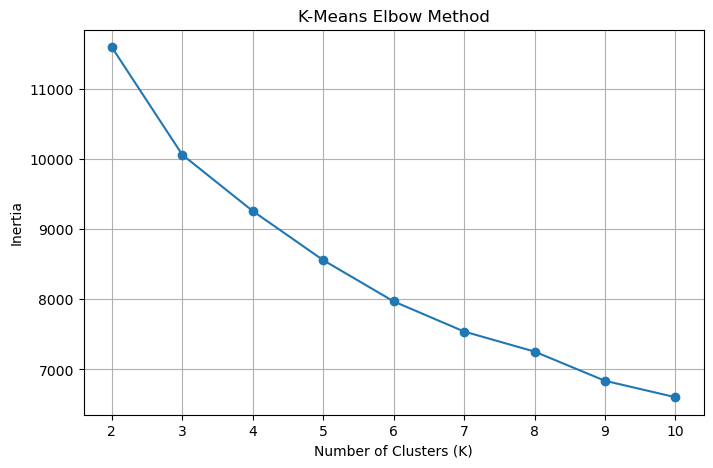

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(k_values)
plt.grid(True)

plt.show()

## 4. K-Means Clustering

Based on the elbow method, K=5 is selected as a practical number of clusters.

The K-Means algorithm is fitted on the standardized diagnostic features using five clusters. A fixed random state is used to ensure reproducibility.

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster_scaled)

print("K-Means clustering completed.")
print("Number of clusters:", len(np.unique(cluster_labels)))

K-Means clustering completed.
Number of clusters: 5


C:\Users\nilsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


## 5. Cluster Size and Diagnosis Composition

The number of observations in each K-Means cluster is examined.

The original diagnosis labels are then used only for interpretation of the clusters. They are not used to train the clustering algorithm.

This allows us to describe the proportion of benign and malignant observations within each feature-based cluster.

In [26]:
# Create a DataFrame for cluster analysis
cluster_analysis = X_cluster.copy()

cluster_analysis["Cluster"] = cluster_labels
cluster_analysis["Diagnosis"] = diagnosis.values

# Count observations by cluster and diagnosis
cluster_composition = pd.crosstab(
    cluster_analysis["Cluster"],
    cluster_analysis["Diagnosis"]
)

# Add total observations in each cluster
cluster_composition["Total"] = cluster_composition.sum(axis=1)

cluster_composition

Diagnosis,B,M,Total
Cluster,,,
0,185,19,204
1,153,8,161
2,0,99,99
3,0,35,35
4,19,51,70


### 5.1 Malignant Percentage by Cluster

The percentage of malignant observations within each cluster is calculated to better understand the diagnosis composition of the feature-based clusters.

The diagnosis labels are used only for post-clustering interpretation and were not used during K-Means training.

In [29]:
cluster_composition["Malignant_Percentage"] = (
    cluster_composition["M"]
    / cluster_composition["Total"]
    * 100
)

cluster_composition["Malignant_Percentage"] = (
    cluster_composition["Malignant_Percentage"].round(2)
)

cluster_composition

Diagnosis,B,M,Total,Malignant_Percentage
Cluster,,,,
0,185,19,204,9.31
1,153,8,161,4.97
2,0,99,99,100.00
3,0,35,35,100.00
4,19,51,70,72.86


## 6. Cluster Feature Profiles

The mean values of the diagnostic features are calculated for each cluster.

The features with the largest differences between clusters help describe the characteristics of each feature-based group.

These profiles are used for exploratory interpretation and do not represent clinical diagnostic categories.

In [32]:
# Calculate mean feature values for each cluster
cluster_feature_means = cluster_analysis.groupby("Cluster")[X_cluster.columns].mean()

cluster_feature_means.round(2)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
Cluster,,,,,,,,,,,,,,,,,,,,,
0,13.02,18.63,83.34,531.12,0.08,0.06,0.03,0.02,0.16,0.06,...,14.40,24.62,93.13,648.51,0.11,0.15,0.14,0.07,0.26,0.07
1,11.50,17.64,74.21,413.12,0.10,0.09,0.05,0.03,0.18,0.07,...,12.71,23.23,83.00,502.57,0.14,0.20,0.18,0.08,0.28,0.08
2,18.48,21.41,121.14,1073.55,0.10,0.12,0.14,0.09,0.18,0.06,...,22.46,28.86,148.13,1573.43,0.14,0.30,0.39,0.17,0.30,0.08
3,21.38,22.40,144.19,1442.94,0.11,0.21,0.27,0.14,0.21,0.07,...,26.42,28.65,181.62,2149.71,0.14,0.48,0.58,0.24,0.33,0.10
4,13.62,20.44,90.60,585.54,0.11,0.17,0.17,0.07,0.21,0.07,...,16.07,28.41,109.27,811.87,0.16,0.49,0.56,0.17,0.36,0.12


### 6.1 Most Distinguishing Features

Because the diagnostic features have different numerical scales, standardized cluster means are used to identify the features that differ most across clusters.

For each feature, the range between its highest and lowest cluster mean is calculated. Features with larger ranges are considered more useful for describing differences between the feature-based clusters.

This analysis is exploratory and is not intended to define clinical diagnostic thresholds.

In [35]:
# Create a DataFrame containing the standardized features
scaled_cluster_df = pd.DataFrame(
    X_cluster_scaled,
    columns=X_cluster.columns
)

scaled_cluster_df["Cluster"] = cluster_labels

# Calculate standardized mean values for each cluster
scaled_cluster_means = (
    scaled_cluster_df
    .groupby("Cluster")
    .mean()
)

# Calculate the range of each feature across clusters
feature_ranges = (
    scaled_cluster_means.max()
    - scaled_cluster_means.min()
)

# Select the 10 most distinguishing features
top_distinguishing_features = (
    feature_ranges
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

top_distinguishing_features

perimeter_se           3.06
concave_points_mean    3.04
perimeter_worst        2.94
area_mean              2.93
concavity_mean         2.93
radius_se              2.92
area_se                2.90
area_worst             2.90
perimeter_mean         2.88
radius_worst           2.84
dtype: float64

## 7. K-Means Cluster Profiles

The K-Means clusters are summarized using their size, diagnosis composition, malignant percentage, and the most relevant distinguishing features.

These profiles provide a concise descriptive view of the feature-based groups identified by K-Means.

In [38]:
# Create a summary table for the five clusters

cluster_profiles = cluster_composition[
    ["B", "M", "Total", "Malignant_Percentage"]
].copy()

cluster_profiles.columns = [
    "Benign",
    "Malignant",
    "Total",
    "Malignant_Percentage"
]

cluster_profiles

,Benign,Malignant,Total,Malignant_Percentage
Cluster,,,,
0,185,19,204,9.31
1,153,8,161,4.97
2,0,99,99,100.00
3,0,35,35,100.00
4,19,51,70,72.86


## 8. Hierarchical Clustering

Hierarchical clustering is performed as a second unsupervised clustering method, as required by the project.

The standardized diagnostic features are used so that differences in feature scale do not dominate the distance calculations.

A dendrogram is used to visualize the hierarchical relationships among observations and to identify a practical cluster structure.

In [41]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Perform hierarchical clustering using Ward's method
linkage_matrix = linkage(
    X_cluster_scaled,
    method="ward"
)

print("Hierarchical clustering completed.")
print("Linkage matrix shape:", linkage_matrix.shape)

Hierarchical clustering completed.
Linkage matrix shape: (568, 4)


### 8.1 Hierarchical Clustering Dendrogram

The dendrogram visualizes the hierarchical relationships between observations.

Ward's linkage method combines observations or groups of observations while minimizing the increase in within-cluster variance. The dendrogram helps identify a practical level at which the observations can be divided into groups.

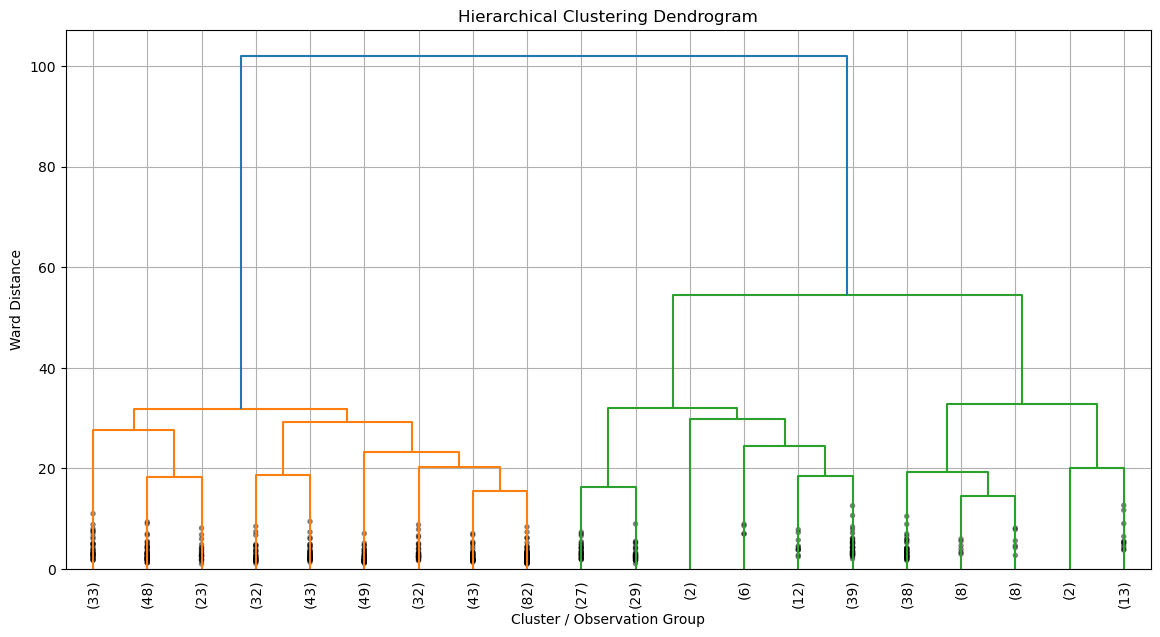

In [44]:
plt.figure(figsize=(14, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster / Observation Group")
plt.ylabel("Ward Distance")
plt.grid(True)

plt.show()

### 8.2 Creating Hierarchical Clusters

Based on the dendrogram, five clusters are selected for the hierarchical clustering analysis.

The clusters are created using the hierarchical linkage matrix. The diagnosis labels are not used to create the clusters; they are used only afterward to describe the composition of the resulting feature-based groups.

In [47]:
from scipy.cluster.hierarchy import fcluster

# Create 5 hierarchical clusters
hierarchical_labels = fcluster(
    linkage_matrix,
    t=5,
    criterion="maxclust"
)

print("Hierarchical clustering completed.")
print("Number of clusters:", len(np.unique(hierarchical_labels)))

Hierarchical clustering completed.
Number of clusters: 5


### 8.3 Hierarchical Cluster Size and Diagnosis Composition

The size and diagnosis composition of each hierarchical cluster are examined.

The diagnosis labels are used only for post-clustering interpretation. They were not used during the hierarchical clustering process.

In [50]:
# Create a DataFrame for hierarchical cluster analysis
hierarchical_analysis = X_cluster.copy()

hierarchical_analysis["Cluster"] = hierarchical_labels
hierarchical_analysis["Diagnosis"] = diagnosis.values

# Count benign and malignant observations in each cluster
hierarchical_composition = pd.crosstab(
    hierarchical_analysis["Cluster"],
    hierarchical_analysis["Diagnosis"]
)

# Add total observations in each cluster
hierarchical_composition["Total"] = hierarchical_composition.sum(axis=1)

hierarchical_composition

Diagnosis,B,M,Total
Cluster,,,
1,337,48,385
2,0,56,56
3,0,59,59
4,6,48,54
5,14,1,15


### 8.4 Malignant Percentage by Hierarchical Cluster

The percentage of malignant observations within each hierarchical cluster is calculated to describe the diagnosis composition of the feature-based groups.

The diagnosis labels are used only for post-clustering interpretation and were not used during hierarchical clustering.

In [53]:
hierarchical_composition["Malignant_Percentage"] = (
    hierarchical_composition["M"]
    / hierarchical_composition["Total"]
    * 100
)

hierarchical_composition["Malignant_Percentage"] = (
    hierarchical_composition["Malignant_Percentage"].round(2)
)

hierarchical_composition

Diagnosis,B,M,Total,Malignant_Percentage
Cluster,,,,
1,337,48,385,12.47
2,0,56,56,100.00
3,0,59,59,100.00
4,6,48,54,88.89
5,14,1,15,6.67


### 8.5 Hierarchical Cluster Profiles

The hierarchical clusters are summarized using their size, benign and malignant composition, and malignant percentage.

These profiles provide a descriptive view of the feature-based groups identified by hierarchical clustering.

In [58]:
hierarchical_profiles = hierarchical_composition[
    ["B", "M", "Total", "Malignant_Percentage"]
].copy()

hierarchical_profiles.columns = [
    "Benign",
    "Malignant",
    "Total",
    "Malignant_Percentage"
]

hierarchical_profiles

,Benign,Malignant,Total,Malignant_Percentage
Cluster,,,,
1,337,48,385,12.47
2,0,56,56,100.00
3,0,59,59,100.00
4,6,48,54,88.89
5,14,1,15,6.67


### 8.6 Hierarchical Cluster Feature Profiles

The mean value of each diagnostic feature is calculated for every hierarchical cluster.

Because the clustering was performed on standardized features, standardized cluster means are used to identify the features that differ most across the hierarchical clusters.

In [61]:
# Create a DataFrame using standardized clustering features
scaled_hierarchical_df = pd.DataFrame(
    X_cluster_scaled,
    columns=X_cluster.columns
)

scaled_hierarchical_df["Cluster"] = hierarchical_labels

# Calculate standardized mean feature values for each cluster
hierarchical_feature_means = (
    scaled_hierarchical_df
    .groupby("Cluster")
    .mean()
)

# Calculate the range of each feature across clusters
hierarchical_feature_ranges = (
    hierarchical_feature_means.max()
    - hierarchical_feature_means.min()
)

# Select the 10 most distinguishing features
top_hierarchical_features = (
    hierarchical_feature_ranges
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

top_hierarchical_features

fractal_dimension_se      4.04
concavity_se              3.63
fractal_dimension_mean    3.44
compactness_se            3.10
radius_worst              2.84
perimeter_worst           2.81
area_worst                2.78
radius_mean               2.74
perimeter_mean            2.71
area_mean                 2.69
dtype: float64

## 9. Clustering Interpretation

Both K-Means and hierarchical clustering identified feature-based groups within the breast tumor dataset.

K-Means produced five clusters with different diagnosis compositions. Two clusters contained only malignant observations, while other clusters contained predominantly benign observations or a mixture of benign and malignant observations.

Hierarchical clustering also produced five groups with distinct diagnosis compositions. Two clusters contained only malignant observations, while another cluster was predominantly malignant and the remaining clusters were predominantly benign.

The clustering results show that the diagnostic measurements contain distinct patterns of feature similarity. However, the clusters are descriptive, feature-based groups and should not be interpreted as clinical diagnostic categories.

The diagnosis labels were not used to train either clustering method. They were used only after clustering to examine the benign and malignant composition of the resulting groups.

### 9.1 Comparison of K-Means and Hierarchical Clustering

The two clustering methods are compared based on the number of clusters and the diagnosis composition observed after clustering.

The cluster labels from the two methods are independent and therefore their numerical labels are not directly matched. The comparison is used to understand whether both methods reveal similar feature-based patterns in the dataset.

In [65]:
# Create a summary comparison of the two clustering methods

kmeans_summary = cluster_profiles[
    ["Benign", "Malignant", "Total", "Malignant_Percentage"]
].copy()

hierarchical_summary = hierarchical_profiles[
    ["Benign", "Malignant", "Total", "Malignant_Percentage"]
].copy()

print("K-Means Cluster Profiles")
display(kmeans_summary)

print("\nHierarchical Cluster Profiles")
display(hierarchical_summary)

K-Means Cluster Profiles


,Benign,Malignant,Total,Malignant_Percentage
Cluster,,,,
0,185,19,204,9.31
1,153,8,161,4.97
2,0,99,99,100.00
3,0,35,35,100.00
4,19,51,70,72.86



Hierarchical Cluster Profiles


,Benign,Malignant,Total,Malignant_Percentage
Cluster,,,,
1,337,48,385,12.47
2,0,56,56,100.00
3,0,59,59,100.00
4,6,48,54,88.89
5,14,1,15,6.67


## 10. Clustering Conclusion

K-Means and hierarchical clustering were applied to the standardized diagnostic features to identify feature-based patterns in the dataset.

K-Means produced five clusters with malignant percentages ranging from 4.97% to 100.00%. Hierarchical clustering also produced five clusters, with malignant percentages ranging from 6.67% to 100.00%.

Both methods identified groups with different distributions of diagnostic measurements and diagnosis composition. The most distinguishing features varied across the clusters, indicating that multiple diagnostic measurements contribute to the observed feature-based patterns.

These clustering results are exploratory and descriptive. The diagnosis labels were not used during clustering and the resulting clusters should not be interpreted as clinical diagnostic categories.

Overall, the clustering analysis provides an additional unsupervised perspective on the structure of the diagnostic measurements and complements the supervised Random Forest classification analysis.